In [7]:
import pandas as pd
import numpy as np

In [8]:
df=pd.read_csv("/content/drive/MyDrive/archive.zip")
print(df.head())
print("information")
print(df.info())
print("Describing my data")
print(df.describe())

   Unnamed: 0                                  Name  Rating  Spec_score  \
0           0                 Samsung Galaxy F14 5G    4.65          68   
1           1                    Samsung Galaxy A11    4.20          63   
2           2                    Samsung Galaxy A13    4.30          75   
3           3                    Samsung Galaxy F23    4.10          73   
4           4  Samsung Galaxy A03s (4GB RAM + 64GB)    4.10          69   

                       No_of_sim       Ram            Battery     Display  \
0  Dual Sim, 3G, 4G, 5G, VoLTE,   4 GB RAM  6000 mAh Battery   6.6 inches   
1      Dual Sim, 3G, 4G, VoLTE,   2 GB RAM  4000 mAh Battery   6.4 inches   
2      Dual Sim, 3G, 4G, VoLTE,   4 GB RAM  5000 mAh Battery   6.6 inches   
3      Dual Sim, 3G, 4G, VoLTE,   4 GB RAM   6000 mAh Battery  6.4 inches   
4      Dual Sim, 3G, 4G, VoLTE,   4 GB RAM  5000 mAh Battery   6.5 inches   

                                              Camera  \
0    50 MP + 2 MP Dual Rear &a

In [9]:
print(" any missing values")
print(df.isnull())

 any missing values
      Unnamed: 0   Name  Rating  Spec_score  No_of_sim    Ram  Battery  \
0          False  False   False       False      False  False    False   
1          False  False   False       False      False  False    False   
2          False  False   False       False      False  False    False   
3          False  False   False       False      False  False    False   
4          False  False   False       False      False  False    False   
...          ...    ...     ...         ...        ...    ...      ...   
1365       False  False   False       False      False  False    False   
1366       False  False   False       False      False  False    False   
1367       False  False   False       False      False  False    False   
1368       False  False   False       False      False  False    False   
1369       False  False   False       False      False  False    False   

      Display  Camera  External_Memory  Android_version  Price  company  \
0       False   

In [10]:
print(df.isnull().sum())

Unnamed: 0             0
Name                   0
Rating                 0
Spec_score             0
No_of_sim              0
Ram                    0
Battery                0
Display                0
Camera                 0
External_Memory        0
Android_version      443
Price                  0
company                0
Inbuilt_memory        19
fast_charging         89
Screen_resolution      2
Processor             28
Processor_name         0
dtype: int64


In [11]:
print(df.dropna())

      Unnamed: 0                                  Name  Rating  Spec_score  \
0              0                 Samsung Galaxy F14 5G    4.65          68   
1              1                    Samsung Galaxy A11    4.20          63   
2              2                    Samsung Galaxy A13    4.30          75   
4              4  Samsung Galaxy A03s (4GB RAM + 64GB)    4.10          69   
5              5                 Samsung Galaxy M13 5G    4.40          75   
...          ...                                   ...     ...         ...   
1365        1365                               TCL 40R    4.05          75   
1366        1366                 TCL 50 XL NxtPaper 5G    4.10          80   
1367        1367                 TCL 50 XE NxtPaper 5G    4.00          80   
1368        1368                    TCL 40 NxtPaper 5G    4.50          79   
1369        1369                           TCL Trifold    4.65          93   

                                No_of_sim        Ram           

In [12]:
print(df.fillna(df.mean(numeric_only=True),inplace=True))
print(df.fillna("Unknown",inplace=True))


None
None


In [13]:
print(df.isnull().sum())

Unnamed: 0           0
Name                 0
Rating               0
Spec_score           0
No_of_sim            0
Ram                  0
Battery              0
Display              0
Camera               0
External_Memory      0
Android_version      0
Price                0
company              0
Inbuilt_memory       0
fast_charging        0
Screen_resolution    0
Processor            0
Processor_name       0
dtype: int64


In [14]:
print("hello this is feature extraction")
df["Ram"]=df["Ram"].str.extract(r"(\d+)").astype(int)


hello this is feature extraction


In [15]:
df["Battery"]=df["Battery"].astype(str).str.extract(r"(\d+)").fillna(0).astype(int)

In [16]:
df["Camera"]=df["Camera"].str.extract(r"(\d+)").fillna(0).astype(int)

In [17]:
df["Display"]=df["Display"].str.extract(r"(\d+\.?\d*)").astype(float)

In [18]:
df["Inbuilt_memory"]=df["Inbuilt_memory"].str.extract(r"(\d+)").fillna(0).astype(int)

In [19]:
df["fast_charging"]=df["fast_charging"].str.extract(r"(\d+)").fillna(0).astype(int)

In [20]:
df["Screen_resolution"]=df["Screen_resolution"].str.extract(r"(\d+)").fillna(0).astype(int)

In [21]:
df["Android_version"]=df["Android_version"].str.extract(r"(\d+)").fillna(0).astype(int)

In [22]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Name"]=le.fit_transform(df["Name"])



In [23]:
df.drop("Name", axis=1, inplace=True)

In [24]:

df["company"]=le.fit_transform(df["company"])


In [25]:
df.drop("company", axis=1, inplace=True)

In [26]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [27]:

df["Price"]=df["Price"].str.replace(",","")
df["Price"]=df["Price"].astype(int)

In [28]:
df.drop(["Processor_name", "External_Memory", "No_of_sim","Processor"], axis=1, inplace=True)

In [29]:
df.dtypes

,0
Rating,float64
Spec_score,int64
Ram,int64
Battery,int64
Display,float64
Camera,int64
Android_version,int64
Price,int64
Inbuilt_memory,int64
fast_charging,int64


In [30]:
print("feature extraction 100% completed")

feature extraction 100% completed


In [31]:
X=df.drop("Price", axis=1)
y=df["Price"]

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=15, n_estimators=300, random_state=42)

In [34]:
y_pred=rf.predict(X_test)
print("predicting prices")

predicting prices


In [35]:
print("Evaluating")
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MSE:", mean_squared_error(y_test, y_pred))



Evaluating
MAE: 6807.572324347765
R2 Score: 0.8388842250994901
RMSE: 12052.072153692186
MSE: 145252443.19780263


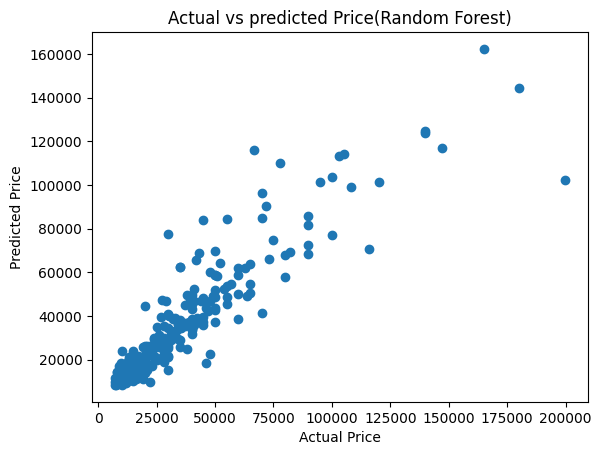

In [36]:

import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs predicted Price(Random Forest)")
plt.show()

In [37]:
import pandas as pd
importance=rf.feature_importances_
features=X.columns
imp_df = pd.DataFrame({'Feature': features, 'Importance':importance}).sort_values(by='Importance', ascending=False)
print(imp_df)

             Feature  Importance
1         Spec_score    0.531181
5             Camera    0.105523
2                Ram    0.077560
4            Display    0.069190
9  Screen_resolution    0.067959
8      fast_charging    0.047190
3            Battery    0.038302
6    Android_version    0.026476
0             Rating    0.019314
7     Inbuilt_memory    0.017305


In [38]:
print("spec_score, Camera are the most important features affecting Price")

spec_score, Camera are the most important features affecting Price


In [41]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"

with zipfile.ZipFile(zip_path, "r") as zip_file:
    print("Files inside archive.zip:")
    print(zip_file.namelist())

Files inside archive.zip:
['mobile phone price prediction.csv']


In [42]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"

with zipfile.ZipFile(zip_path, "r") as zip_file:
    zip_file.extractall("/content/mobile_price_data")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [43]:
import os

print(os.listdir("/content/mobile_price_data"))

['mobile phone price prediction.csv']


In [44]:
from google.colab import files

files.download("/content/mobile_price_data/mobile phone price prediction.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>